# Latest-session evaluation and fail-closed release

This notebook evaluates the locked V2 pipeline on the latest completed Fall/Winter and Summer sessions, `20259` and `20265`. Failed pre-locked gates produce a diagnostic report and do not overwrite the production model.

In [1]:
from __future__ import annotations
import hashlib, inspect, json, os, platform, sys
from pathlib import Path
import joblib, matplotlib.pyplot as plt, numpy as np, pandas as pd, sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name == 'v2' or not (PROJECT_ROOT / 'notebooks').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / 'data' / 'Enrollment-Data-master'
ARTIFACT_ROOT = PROJECT_ROOT / 'artifacts' / 'v2'
CACHE_ROOT = ARTIFACT_ROOT / 'cache'
MODEL_ROOT = PROJECT_ROOT / 'model'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 20260812
SESSION_ORDER = ['20229','20235','20239','20245','20249','20255','20259','20265']
SEASONS = {'fall_winter':['20229','20239','20249','20259'], 'summer':['20235','20245','20255','20265']}
FINAL_TEST = {'fall_winter':'20259', 'summer':'20265'}
DEVELOPMENT = {k:[s for s in v if s != FINAL_TEST[k]] for k,v in SEASONS.items()}

def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''): h.update(chunk)
    return h.hexdigest()

def fingerprint(payload) -> str:
    return hashlib.sha256(json.dumps(payload, sort_keys=True, default=str).encode()).hexdigest()[:16]

def versions():
    return {'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
            'scikit_learn':sklearn.__version__,'joblib':joblib.__version__}
BASE = ['position_to_capacity','waitlist_to_capacity','days_to_deadline','movement_3d','movement_7d','position','waitlist','capacity','capacity_changed_7d','position_to_waitlist','days_squared','log_waitlist','movement_velocity_7d']
CONTEXT = BASE + ['near_deadline_7d','days_under_7','days_under_14','days_over_60','position_ratio_near_7d','waitlist_ratio_near_7d','rank_over_30pct','campus_erin','campus_scar','term_winter','term_full_year','winter_near_7d','scar_near_7d']
RANK_MONOTONIC={'position_to_capacity':-1,'position':-1,'position_to_waitlist':-1,'position_ratio_near_7d':-1,'rank_over_30pct':-1}
def targeted(frame):
    f=frame.copy(); days=f.days_to_deadline.astype(float); near=(days<=7).astype('float32')
    f['near_deadline_7d']=near; f['days_under_7']=(7-days).clip(lower=0); f['days_under_14']=(14-days).clip(lower=0); f['days_over_60']=(days-60).clip(lower=0)
    f['position_ratio_near_7d']=f.position_to_capacity*near; f['waitlist_ratio_near_7d']=f.waitlist_to_capacity*near
    f['rank_over_30pct']=(f.position_to_capacity>.30).astype('float32'); f['campus_erin']=(f.campus=='ERIN').astype('float32'); f['campus_scar']=(f.campus=='SCAR').astype('float32')
    f['term_winter']=(f.term=='winter').astype('float32'); f['term_full_year']=(f.term=='full_year').astype('float32')
    f['winter_near_7d']=f.term_winter*near; f['scar_near_7d']=f.campus_scar*near
    return f
def make_model(features, *, leaf=15, l2=3.0):
    constraints=[RANK_MONOTONIC.get(x,0) for x in features]
    return Pipeline([('features',ColumnTransformer([('numeric',SimpleImputer(strategy='median'),features)],remainder='drop')),
      ('model',HistGradientBoostingClassifier(max_iter=200,learning_rate=.05,max_leaf_nodes=leaf,l2_regularization=l2,monotonic_cst=constraints,random_state=RANDOM_STATE))])
def ece(y,p,w,bins=10):
    edges=np.linspace(0,1,bins+1); ids=np.clip(np.digitize(p,edges)-1,0,bins-1); total=w.sum(); out=0
    for b in range(bins):
        m=ids==b
        if m.any(): out+=w[m].sum()/total*abs(np.average(y[m],weights=w[m])-np.average(p[m],weights=w[m]))
    return float(out)
def metrics(frame,p):
    y=frame.cleared.to_numpy(); w=frame.model_weight.to_numpy(); p=np.clip(np.asarray(p),1e-6,1-1e-6)
    auc=roc_auc_score(y,p,sample_weight=w) if np.unique(y).size>1 else np.nan
    return {'brier':brier_score_loss(y,p,sample_weight=w),'log_loss':log_loss(y,p,sample_weight=w,labels=[0,1]),'ece':ece(y,p,w),'auc':auc,'accuracy':np.average((p>=.5)==y,weights=w)}
def export_tree(predictor):
    return [{'value':float(n['value']),'feature':int(n['feature_idx']),'threshold':float(n['num_threshold']),
      'missing_left':bool(n['missing_go_to_left']),'left':int(n['left']),'right':int(n['right']),'leaf':bool(n['is_leaf'])} for n in predictor.nodes]
def export_model(pipeline,features):
    estimator=pipeline.named_steps['model']; imputer=pipeline.named_steps['features'].named_transformers_['numeric']
    return {'numeric_features':features,'imputation_values':[float(x) for x in imputer.statistics_],
      'baseline_log_odds':float(np.asarray(estimator._baseline_prediction).ravel()[0]),
      'trees':[export_tree(stage[0]) for stage in estimator._predictors],'calibration':{'method':'none'}}


## Load locked specification and latest completed sessions

In [2]:
# Load only a locked specification derived from the exact current cache manifest.
cache_manifest=json.loads((ARTIFACT_ROOT/'cache-manifest.json').read_text()); current_cache_fingerprint=fingerprint(cache_manifest)
candidates=[(p,c) for p,c in [(p,json.loads(p.read_text())) for p in ARTIFACT_ROOT.glob('locked-spec-*.json')]
  if 'release_thresholds' in c and c.get('cache_fingerprint')==current_cache_fingerprint]
if not candidates: raise RuntimeError('No locked specification matches the current cache; rerun Notebooks 2 and 3')
locked_path,locked=max(candidates,key=lambda item:item[0].stat().st_mtime_ns); spec=locked['spec']; features=spec['features']; THRESHOLDS=locked['release_thresholds']
MAX_NEGATIVE_CENSOR_GAP_HOURS=cache_manifest['negative_censor_gap_hours_max']; CACHE_VERSION=int(cache_manifest['cache_version'])
samples={s:targeted(pd.read_pickle(CACHE_ROOT/f'{s}-positions-v{CACHE_VERSION}.pkl')) for s in SESSION_ORDER}
daily={s:pd.read_pickle(CACHE_ROOT/f'{s}-daily-v{CACHE_VERSION}.pkl') for s in SESSION_ORDER}


## Complete-trajectory historical baseline and simple rules

In [3]:
def historical_probability(train_sessions,valid):
    result=np.full(len(valid),np.nan); queries=valid[['course_code','days_to_deadline','position']].reset_index(drop=True); queries['_row']=np.arange(len(queries))
    histories=pd.concat([daily[s] for s in train_sessions],ignore_index=True)
    histories_by_course={code:[offering.sort_values('days_to_deadline') for _,offering in course.groupby('offering_id',sort=False)] for code,course in histories.groupby('course_code',sort=False)}
    for code,course_queries in queries.groupby('course_code',sort=False):
        offerings=histories_by_course.get(code,[])
        if not offerings: continue
        for target_day,day_queries in course_queries.groupby('days_to_deadline',sort=False):
            evidence=[]
            for offering in offerings:
                nearest=offering.iloc[np.abs(offering.days_to_deadline.to_numpy()-target_day).argmin()]
                evidence.append((int(nearest.waitlist),float(nearest.observed_downward_movement),float(nearest.terminal_gap_hours)))
            evidence=np.asarray(evidence)
            for position,rank_queries in day_queries.groupby('position',sort=False):
                usable=(evidence[:,0]>=position) & ((evidence[:,1]>=position) | (evidence[:,2]<=MAX_NEGATIVE_CENSOR_GAP_HOURS))
                if usable.any(): result[rank_queries._row.to_numpy()]=np.mean(evidence[usable,1]>=position)
    return result
def apply_locked_calibration(season,p):
    params=locked['calibration_parameters'][season]; clipped=np.clip(np.asarray(p),1e-6,1-1e-6)
    if params['method']=='none': return clipped
    if params['method']=='platt':
        score=params['coefficient']*np.log(clipped/(1-clipped))+params['intercept']
        return 1/(1+np.exp(-score))
    if params['method']=='isotonic':
        return np.interp(clipped,params['x'],params['y'],left=params['y'][0],right=params['y'][-1])
    raise ValueError(f'Unknown locked calibration method: {params["method"]}')


## Latest-session evaluation with clustered uncertainty

In [4]:
def cluster_ci(frame,p,reps=2000):
    work=pd.DataFrame({'offering_id':frame.offering_id.to_numpy(),'weight':frame.model_weight.to_numpy(),'error':frame.model_weight.to_numpy()*(frame.cleared.to_numpy()-np.asarray(p))**2})
    offering=work.groupby('offering_id',sort=False).agg(error=('error','sum'),weight=('weight','sum')).to_numpy(); rng=np.random.default_rng(RANDOM_STATE)
    chosen=rng.integers(0,len(offering),size=(reps,len(offering))); values=offering[chosen,0].sum(axis=1)/offering[chosen,1].sum(axis=1)
    return np.quantile(values,[.025,.975]).tolist()
rows=[]; fitted={}; evaluation_predictions={}
for season,test_session in FINAL_TEST.items():
    print(f'{season}: fitting final evaluation models',flush=True)
    train_sessions=DEVELOPMENT[season]; train=pd.concat([samples[s] for s in train_sessions],ignore_index=True); test=samples[test_session]
    model=make_model(**spec); model.fit(train[features],train.cleared,model__sample_weight=train.model_weight); fitted[season]=model
    oracle=apply_locked_calibration(season,model.predict_proba(test[features])[:,1]); literal=(test.position_to_capacity<=.10).astype(float).to_numpy(); print(f'{season}: calculating grouped historical baseline',flush=True); history=historical_probability(train_sessions,test)
    capacity_model=Pipeline([('imputer',SimpleImputer(strategy='median')),('model',LogisticRegression(C=1e6,solver='lbfgs'))])
    capacity_model.fit(train[['position_to_capacity']],train.cleared,model__sample_weight=train.model_weight)
    boosted=capacity_model.predict_proba(test[['position_to_capacity']])[:,1]
    evaluation_predictions[season]={'test':test,'oracle':oracle,'literal_10_percent':literal,'boosted_10_percent':boosted,'historical_percentage':history}
    masks={'all_evaluation':np.ones(len(test),bool),'common_subset':np.isfinite(history)}
    for scope,mask in masks.items():
        methods=['oracle','literal_10_percent','boosted_10_percent']+(['historical_percentage'] if scope=='common_subset' else [])
        for name in methods:
            scored=test.loc[mask]; pred=np.asarray(evaluation_predictions[season][name])[mask]
            rows.append({'season':season,'evaluation_scope':scope,'method':name,'coverage':float(scored.model_weight.sum()/test.model_weight.sum()),**metrics(scored,pred),'brier_ci':cluster_ci(scored,pred)})
final_scores=pd.DataFrame(rows); final_scores

fall_winter: fitting final evaluation models


fall_winter: calculating grouped historical baseline


summer: fitting final evaluation models


summer: calculating grouped historical baseline


,season,evaluation_scope,method,coverage,brier,log_loss,ece,auc,accuracy,brier_ci
0,fall_winter,all_evaluation,oracle,1.000000,0.017018,0.056779,0.006498,0.985272,0.974206,"[0.015430680729605312, 0.018728129961020894]"
1,fall_winter,all_evaluation,literal_10_percent,1.000000,0.051227,0.707729,0.051226,0.500557,0.948773,"[0.04674619376112549, 0.05577985271264475]"
2,fall_winter,all_evaluation,boosted_10_percent,1.000000,0.040597,0.175621,0.002587,0.523232,0.957646,"[0.037303752060532706, 0.04417688574019505]"
3,fall_winter,common_subset,oracle,0.723220,0.014265,0.048138,0.005920,0.987063,0.978697,"[0.01277475404141948, 0.015945491264606936]"
4,fall_winter,common_subset,literal_10_percent,0.723220,0.042534,0.587633,0.042533,0.496827,0.957466,"[0.038272484806648875, 0.04728879117452728]"
5,fall_winter,common_subset,boosted_10_percent,0.723220,0.034238,0.153816,0.004400,0.500781,0.964591,"[0.031053224452927214, 0.03769820871858782]"
6,fall_winter,common_subset,historical_percentage,0.723220,0.022173,0.243777,0.020356,0.841124,0.976017,"[0.019917964182003544, 0.024686035385990745]"
7,summer,all_evaluation,oracle,1.000000,0.049576,0.178992,0.022897,0.921385,0.935585,"[0.042471570360230915, 0.057459762251411396]"
8,summer,all_evaluation,literal_10_percent,1.000000,0.266682,3.684352,0.266681,0.651838,0.733318,"[0.24758246635627337, 0.2870594571500518]"
9,summer,all_evaluation,boosted_10_percent,1.000000,0.077809,0.283810,0.013018,0.686410,0.910601,"[0.06685478554887975, 0.08914025530313312]"


## README benchmark figures

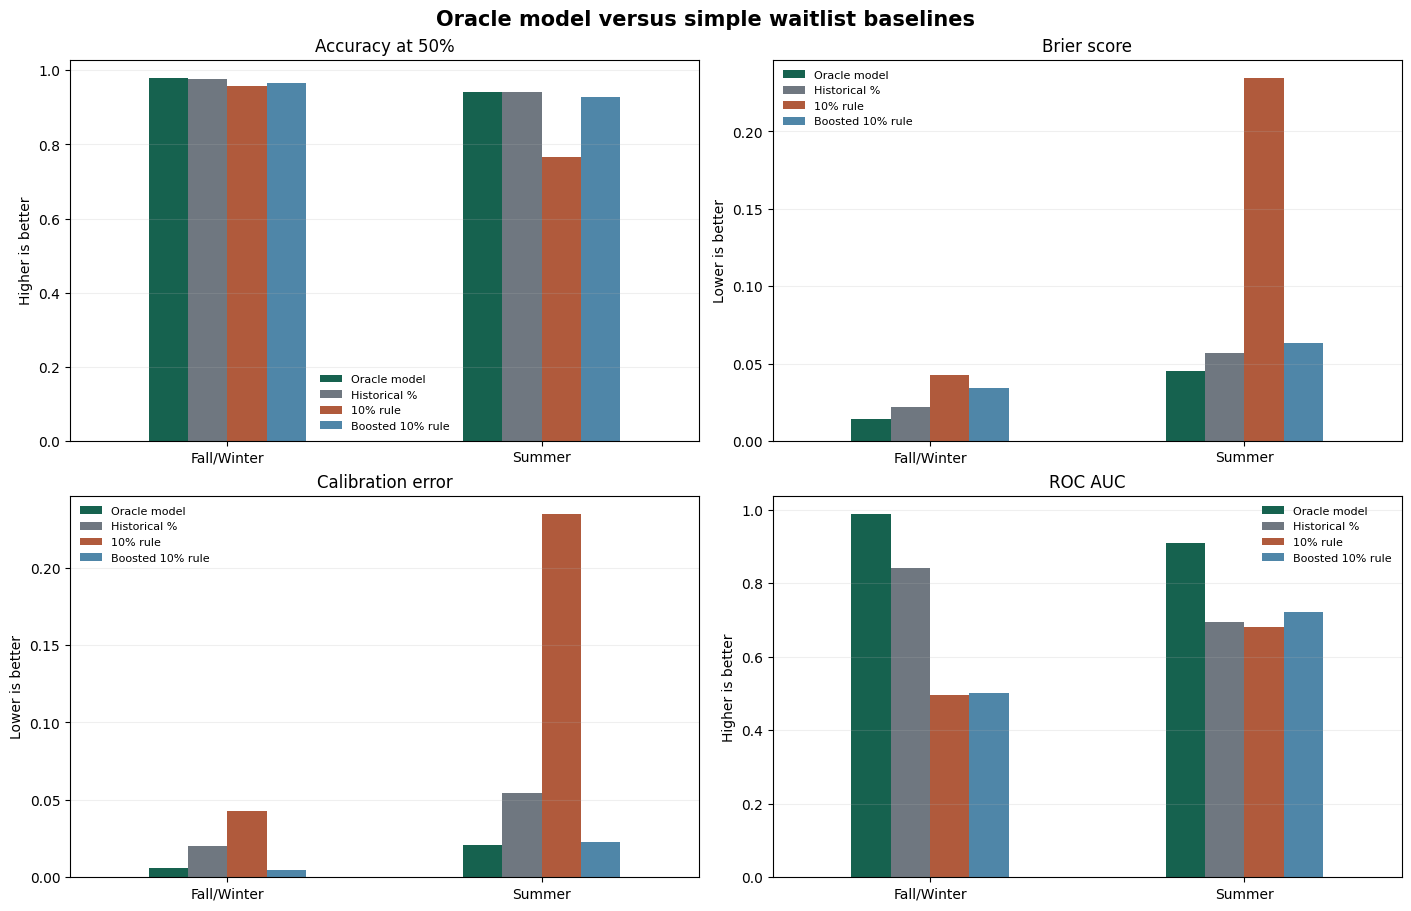

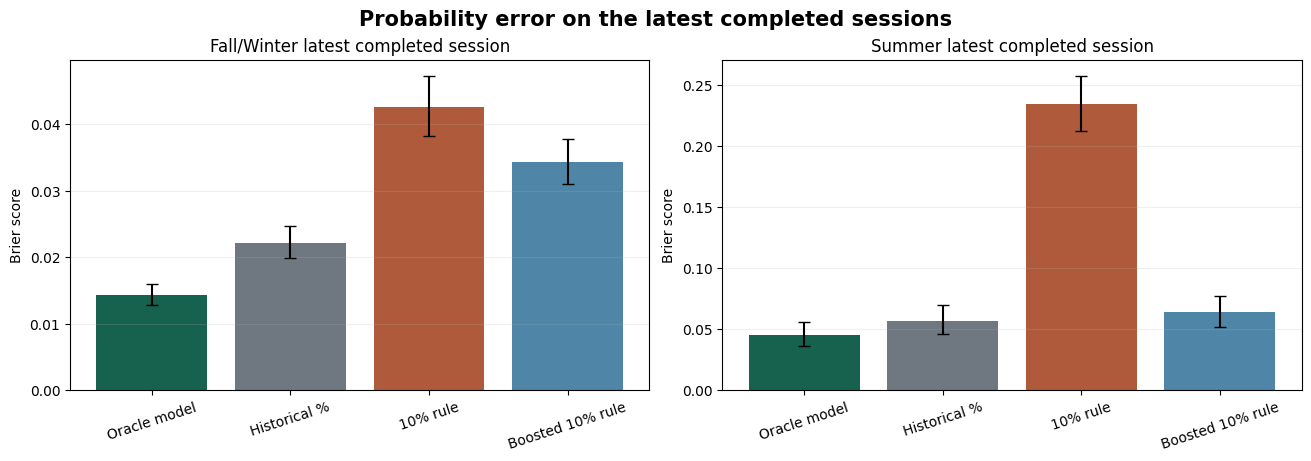

Saved /student/anfazsha/oracle/docs/assets/model-baseline-benchmark.png and /student/anfazsha/oracle/docs/assets/model-chronological-benchmark.png


In [5]:
OUTPUT_ROOT=PROJECT_ROOT/'docs'/'assets'; OUTPUT_ROOT.mkdir(parents=True,exist_ok=True)
methods=['oracle','historical_percentage','literal_10_percent','boosted_10_percent']
labels={'oracle':'Oracle model','historical_percentage':'Historical %','literal_10_percent':'10% rule','boosted_10_percent':'Boosted 10% rule'}
colors={'oracle':'#16624f','historical_percentage':'#6f7780','literal_10_percent':'#b05a3c','boosted_10_percent':'#4f86a8'}
season_names={'fall_winter':'Fall/Winter','summer':'Summer'}
metric_specs=[('accuracy','Accuracy at 50%','Higher is better'),('brier','Brier score','Lower is better'),('ece','Calibration error','Lower is better'),('auc','ROC AUC','Higher is better')]
common=final_scores.loc[final_scores.evaluation_scope.eq('common_subset')].copy()
fig,axes=plt.subplots(2,2,figsize=(14,9),constrained_layout=True)
for ax,(metric,title,direction) in zip(axes.flat,metric_specs):
    table=common.pivot(index='season',columns='method',values=metric).reindex(index=['fall_winter','summer'],columns=methods)
    table.rename(index=season_names,columns=labels).plot(kind='bar',ax=ax,color=[colors[x] for x in methods])
    ax.set(title=title,xlabel='',ylabel=direction); ax.tick_params(axis='x',rotation=0); ax.grid(axis='y',alpha=.2); ax.legend(frameon=False,fontsize=8)
fig.suptitle('Oracle model versus simple waitlist baselines',fontsize=15,fontweight='bold')
benchmark_path=OUTPUT_ROOT/'model-baseline-benchmark.png'; fig.savefig(benchmark_path,dpi=180,bbox_inches='tight',facecolor='white'); plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,4.5),constrained_layout=True)
for ax,season in zip(axes,['fall_winter','summer']):
    table=common.loc[common.season.eq(season)].set_index('method').reindex(methods)
    values=table.brier.to_numpy(); intervals=np.array(table.brier_ci.tolist()); errors=np.vstack([values-intervals[:,0],intervals[:,1]-values])
    ax.bar([labels[x] for x in methods],values,yerr=errors,color=[colors[x] for x in methods],capsize=4)
    ax.set(title=f'{season_names[season]} latest completed session',xlabel='',ylabel='Brier score'); ax.tick_params(axis='x',rotation=18); ax.grid(axis='y',alpha=.2)
fig.suptitle('Probability error on the latest completed sessions',fontsize=15,fontweight='bold')
chronology_path=OUTPUT_ROOT/'model-chronological-benchmark.png'; fig.savefig(chronology_path,dpi=180,bbox_inches='tight',facecolor='white'); plt.show()
print(f'Saved {benchmark_path} and {chronology_path}')

## Apply the pre-locked release gates

In [6]:
def gap(frame,p,mask):
    if not mask.any() or mask.all(): return np.nan
    return abs(np.average(frame.cleared[mask],weights=frame.model_weight[mask])-np.average(np.asarray(p)[mask],weights=frame.model_weight[mask]))
gate_rows=[]
for season,test_session in FINAL_TEST.items():
    test=samples[test_session]; model=fitted[season]; p=apply_locked_calibration(season,model.predict_proba(test[features])[:,1])
    oracle=final_scores.query("season==@season and evaluation_scope=='all_evaluation' and method=='oracle'").iloc[0]; literal=final_scores.query("season==@season and evaluation_scope=='all_evaluation' and method=='literal_10_percent'").iloc[0]
    bins=pd.cut(p,np.linspace(0,1,11),include_lowest=True); probability_bins=[]; total_weight=test.model_weight.sum()
    for interval,g in test.assign(_p=p,_bin=bins).groupby('_bin',observed=True):
        weight_fraction=float(g.model_weight.sum()/total_weight); observed=float(np.average(g.cleared,weights=g.model_weight)); predicted=float(np.average(g._p,weights=g.model_weight)); bin_gap=abs(observed-predicted)
        probability_bins.append({'bin':str(interval),'rows':int(len(g)),'weight_fraction':weight_fraction,'observed':observed,'predicted':predicted,'gap':float(bin_gap),'gate_eligible':bool(weight_fraction>=THRESHOLDS['probability_bin_min_weight_fraction'])})
    eligible_gaps=[item['gap'] for item in probability_bins if item['gate_eligible']]; probability_gap=max(eligible_gaps) if eligible_gaps else float('inf')
    near_deadline_gap=gap(test,p,test.days_to_deadline.le(7).to_numpy()); large_queue_gap=gap(test,p,test.waitlist.ge(100).to_numpy())
    positive_weight_fraction=float(np.average(test.cleared,weights=test.model_weight)); minimum_class_weight_fraction=min(positive_weight_fraction,1-positive_weight_fraction)
    checks={'class_support':bool(minimum_class_weight_fraction>=THRESHOLDS['minimum_class_weight_fraction']),'oracle_brier_lt_literal':bool(oracle.brier<literal.brier),'ece':bool(oracle.ece<=THRESHOLDS['ece_lte']),
      'near_deadline_gap':bool(near_deadline_gap<=THRESHOLDS['near_deadline_gap_lte']),
      'large_queue_gap':bool(large_queue_gap<=THRESHOLDS['large_queue_gap_lte']),
      'max_probability_gap':bool(probability_gap<=THRESHOLDS['max_probability_gap_lte'])}
    gate_rows.append({'season':season,'passed':bool(all(checks.values())),'checks':checks,'positive_weight_fraction':positive_weight_fraction,'minimum_class_weight_fraction':minimum_class_weight_fraction,
      'ece':float(oracle.ece),'near_deadline_gap':float(near_deadline_gap),'large_queue_gap':float(large_queue_gap),'max_probability_gap':float(probability_gap),'probability_bins':probability_bins})
gates=pd.DataFrame(gate_rows); gates


,season,passed,checks,positive_weight_fraction,minimum_class_weight_fraction,ece,near_deadline_gap,large_queue_gap,max_probability_gap,probability_bins
0,fall_winter,True,"{'class_support': True, 'oracle_brier_lt_liter...",0.957646,0.042354,0.006498,0.042210,0.000213,0.064103,"[{'bin': '(-0.001, 0.1]', 'rows': 1706, 'weigh..."
1,summer,False,"{'class_support': True, 'oracle_brier_lt_liter...",0.910588,0.089412,0.022897,0.090389,0.060249,0.156911,"[{'bin': '(-0.001, 0.1]', 'rows': 1594, 'weigh..."


## Refit and export validated and explicitly experimental seasonal models


In [7]:
report={'locked_spec_fingerprint':locked['fingerprint'],'final_test':FINAL_TEST,'scores':final_scores.to_dict('records'),'gates':gate_rows,'thresholds':THRESHOLDS,'versions':versions(),
 'cache_manifest_hash':sha256(ARTIFACT_ROOT/'cache-manifest.json')}
(ARTIFACT_ROOT/'final-evaluation.json').write_text(json.dumps(report,indent=2),encoding='utf-8')
gate_by_season={row['season']:row for row in gate_rows}; models={}
for season,sessions in SEASONS.items():
    training=pd.concat([samples[s] for s in sessions],ignore_index=True); model=make_model(**spec)
    model.fit(training[features],training.cleared,model__sample_weight=training.model_weight)
    exported=export_model(model,features); params=locked['calibration_parameters'][season]
    if params['method']=='platt': exported['calibration']={'method':'platt','parameters':{'coefficient':params['coefficient'],'intercept':params['intercept']}}
    elif params['method']=='isotonic': exported['calibration']={'method':'isotonic','x':params['x'],'y':params['y']}
    gate=gate_by_season[season]; failed_checks=[name for name,passed in gate['checks'].items() if not passed]
    quality='validated' if gate['passed'] else 'experimental'
    models[season]={'quality':quality,'failed_release_checks':failed_checks,'release_diagnostics':{
      'ece':gate['ece'],'near_deadline_gap':gate['near_deadline_gap'],'large_queue_gap':gate['large_queue_gap'],'max_probability_gap':gate['max_probability_gap']},
      'training_sessions':sessions,'final_evaluation':next(x for x in report['scores'] if x['season']==season and x['evaluation_scope']=='all_evaluation' and x['method']=='oracle'),**exported}
artifact={'schema_version':8,'target':'cumulative_observed_downward_movement','model_type':'seasonal_hist_gradient_boosting_bundle','session_routing':{'5':'summer','9':'fall_winter'},
 'release_policy':'validated seasons are production-ready; failed seasons are exported only as explicitly experimental estimates with diagnostics',
 'training_support':{'max_position':int(max(f.position.max() for f in samples.values())),'position_never_exceeds_waitlist':True},
 'provenance':{'locked_spec_fingerprint':locked['fingerprint'],'cache_manifest_hash':report['cache_manifest_hash'],'versions':versions()},'models':models}
candidate=MODEL_ROOT/'oracle-model-schema8.json'; candidate.write_text(json.dumps(artifact,separators=(',',':')),encoding='utf-8')
print(f'Artifact written to {candidate}: '+', '.join(f'{season}={model["quality"]}' for season,model in models.items()))


Artifact written to /student/anfazsha/oracle/model/oracle-model-schema8.json: fall_winter=validated, summer=experimental


## Final interpretation

These scores evaluate the locked V2 pipeline on the latest completed session of each season. Features, calibration, hyperparameters, and release thresholds were fixed before these sessions were loaded by this pipeline. A season passing every pre-locked gate is marked validated. A season that still beats the simple baselines but misses strict calibration gates may be exported only as experimental, with its exact failed checks and diagnostic values embedded in the artifact and disclosed to users.
